# Customer Retention & Churn Analysis

## Exploratory Data Analysis (EDA) - Customer Analysis

The objective of this notebook is to understand customer demographics, customer behavior, revenue contribution, and customer characteristics before analyzing churn drivers.

Key Questions:

1. Who are our customers?
2. How are customers distributed across demographics?
3. What services do customers use?
4. How long do customers stay?
5. Which customer segments generate the most revenue?

## Step 1: Import Required Libraries

### Purpose

Import libraries required for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Step 2: Load Dataset

Load the Telco Customer Churn dataset for exploratory analysis.

In [3]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

## Data Preparation

Convert Total Charges to numeric format before analysis.

In [4]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

## Analysis 1: Gender Distribution

### Business Question

What is the gender distribution of customers?

### Why It Matters

Understanding demographic composition helps identify dominant customer groups.

In [5]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [6]:
gender_pct = round(
    df['Gender'].value_counts(normalize=True) * 100,
    2
)

gender_pct

Gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

### Visualization: Customer Distribution by Gender

The following chart displays the distribution of customers by gender.

The visualization helps determine whether the customer base is balanced across genders and provides a foundation for future churn analysis by customer demographics.

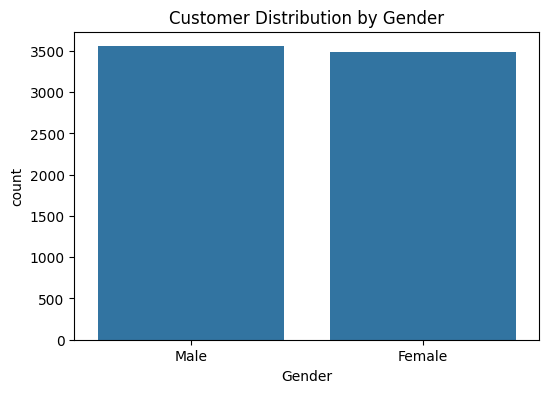

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Customer Distribution by Gender')

plt.show()

### Observation

The customer base is evenly distributed across genders.

- Male Customers: 3,555 (50.48%)
- Female Customers: 3,488 (49.52%)

### Insight

The company serves a balanced customer population with no significant gender dominance.

### Business Impact

Gender alone is unlikely to explain customer churn patterns due to the nearly equal customer distribution.

### Recommendation

Further analysis should evaluate churn rates by gender to determine whether retention behavior differs between male and female customers.

## Analysis 2: Senior Citizen Distribution

### Business Question

What percentage of customers are senior citizens?

### Why It Matters

Different age groups often demonstrate different retention behaviors.

In [8]:
df['Senior Citizen'].value_counts()

Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

In [9]:
senior_pct = round(
    df['Senior Citizen'].value_counts(normalize=True) * 100,
    2
)

senior_pct

Senior Citizen
No     83.79
Yes    16.21
Name: proportion, dtype: float64

### Visualization: Senior Citizen Distribution

The following chart displays the distribution of customers based on senior citizen status.

The visualization helps understand the age composition of the customer base and provides a foundation for future retention and churn analysis across age-related customer segments.

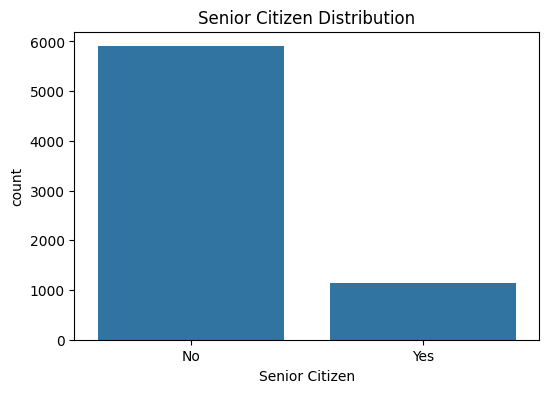

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Senior Citizen'
)

plt.title('Senior Citizen Distribution')

plt.show()

### Observation

The majority of customers are non-senior citizens.

- Non-Senior Citizens: 5,901 (83.79%)
- Senior Citizens: 1,142 (16.21%)

### Insight

Senior citizens represent a relatively small segment of the customer base, while the majority of customers belong to the non-senior category.

This indicates that the company's services are primarily utilized by younger and middle-aged customers.

### Business Impact

Different age groups often exhibit different service preferences, spending behaviors, and retention patterns.

Understanding the behavior of senior citizen customers is important because they may require different engagement and support strategies.

### Recommendation

Compare churn rates between senior citizens and non-senior citizens during the churn analysis phase to determine whether age-related retention strategies are required.

## Analysis 3: Customer Tenure Distribution

### Business Question

How long do customers stay with the company?

### Why It Matters

Customer tenure is a strong indicator of loyalty and retention.

In [8]:
df['Tenure Months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

### Visualization: Customer Tenure Distribution

The following histogram displays the distribution of customer tenure in months.

The visualization helps understand how long customers typically remain with the company and identifies whether the customer base is dominated by newly acquired customers, long-term customers, or a mix of both.

Customer tenure is one of the most important indicators of customer loyalty and retention behavior.

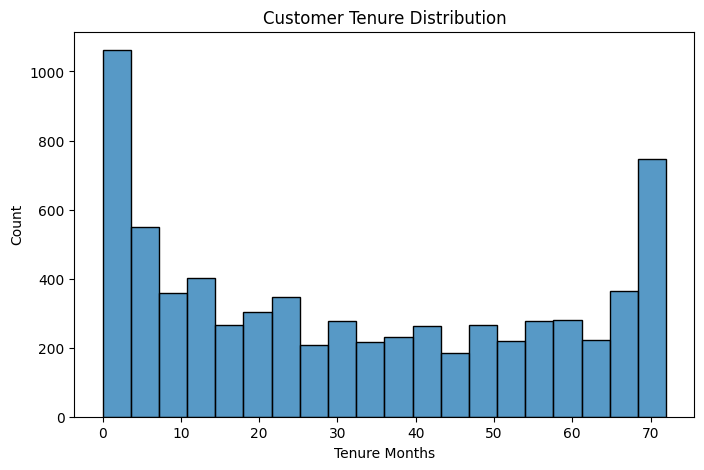

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Tenure Months'],
    bins=20
)

plt.title('Customer Tenure Distribution')

plt.xlabel('Tenure Months')

plt.show()

### Observation

The average customer tenure is 32.37 months, with customer relationships ranging from 0 to 72 months.

Key statistics:

- Average Tenure: 32.37 months
- Median Tenure: 29 months
- 25% of customers stay for 9 months or less
- 50% of customers stay for 29 months or less
- 75% of customers stay for 55 months or less
- Maximum Tenure: 72 months

### Insight

The customer base contains a mix of newly acquired customers and long-term loyal customers. The median tenure of 29 months indicates that a typical customer remains with the company for more than two years.

The presence of customers with very low tenure suggests that a significant portion of the customer base is still in the early stages of the customer lifecycle.

### Business Impact

Based on industry retention patterns, customers with shorter tenure are often more vulnerable to churn because they have not yet established strong service loyalty. This hypothesis will be validated during the churn analysis phase.

Long-tenure customers are likely to contribute higher lifetime value and more stable recurring revenue.

### Recommendation

In the churn analysis phase, compare churn rates across tenure groups to determine whether newer customers are leaving at a higher rate than long-term customers.

Special attention should be given to customers within their first 12 months, as early-stage churn often presents the greatest retention opportunity.

## Analysis 4: Contract Type Distribution

### Business Question

Which contract plans are most popular?

### Why It Matters

Contract type is often one of the strongest predictors of customer churn.

In [10]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
contract_pct = round(
    df['Contract'].value_counts(normalize=True) * 100,
    2
)

contract_pct

Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64

### Visualization: Contract Type Distribution

The following chart displays the distribution of customers across different contract types.

The visualization helps understand customer commitment levels and identifies whether customers prefer short-term or long-term service agreements.

Contract type is one of the most important customer characteristics because it often influences customer loyalty, retention behavior, and revenue generation.

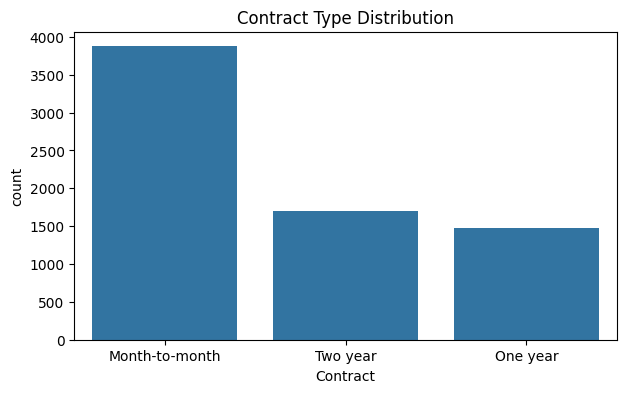

In [11]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='Contract'
)

plt.title('Contract Type Distribution')

plt.show()

### Observation

More than half of the customers are subscribed to Month-to-Month contracts.

Contract Distribution:

- Month-to-Month: 3,875 customers (55.02%)
- Two-Year: 1,695 customers (24.07%)
- One-Year: 1,473 customers (20.91%)

Month-to-Month contracts represent the largest customer segment, accounting for more than half of the customer base.

### Insight

Customers appear to prefer flexible subscription options over long-term contractual commitments.

The high concentration of Month-to-Month customers suggests that a large portion of the customer base has relatively low switching barriers.

### Business Impact

A customer base dominated by Month-to-Month contracts may be more vulnerable to customer attrition because customers can discontinue services without long-term contractual obligations.

At the same time, flexible plans may help attract new customers by reducing commitment requirements.

### Hypothesis

Customers subscribed to Month-to-Month contracts may exhibit higher churn rates compared to customers enrolled in One-Year or Two-Year contracts.

This hypothesis will be validated during the churn analysis phase.

### Recommendation

Analyze churn behavior by contract type to determine whether contract duration is a significant driver of customer retention and customer attrition.

## Analysis 5: Internet Service Distribution

### Business Question

Which internet service type is most commonly used?

### Why It Matters

Internet service type can influence customer satisfaction and churn behavior.

In [12]:
df['Internet Service'].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [11]:
internet_pct = round(
    df['Internet Service'].value_counts(normalize=True) * 100,
    2
)

internet_pct

Internet Service
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64

### Visualization: Internet Service Distribution

The following chart displays the distribution of customers across different internet service categories.

The visualization helps understand customer adoption of internet services and identifies the most popular service offerings within the customer base.

Internet service type is a key business dimension because it influences customer experience, service usage, revenue generation, and potential churn behavior.

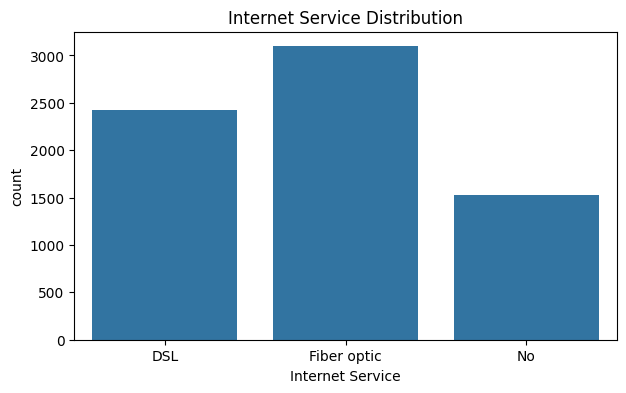

In [13]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x='Internet Service'
)

plt.title('Internet Service Distribution')

plt.show()

### Observation

Fiber Optic is the most widely used internet service among customers.

Internet Service Distribution:

- Fiber Optic: 3,096 customers (43.96%)
- DSL: 2,421 customers (34.37%)
- No Internet Service: 1,526 customers (21.67%)

Nearly 44% of customers subscribe to Fiber Optic services, making it the largest internet service segment.

### Insight

The majority of customers rely on internet-based services, with Fiber Optic being the preferred option.

The strong adoption of Fiber Optic services suggests that customers value higher-speed internet connectivity and advanced service capabilities.

### Business Impact

Since Fiber Optic represents the largest customer segment, changes in customer satisfaction, pricing, service quality, or churn within this segment could significantly impact overall business performance.

Service-related issues affecting Fiber Optic customers may have a larger business impact than issues affecting other service categories.

### Hypothesis

Customer retention behavior may differ across internet service types.

Fiber Optic customers may exhibit different churn patterns compared to DSL customers due to differences in pricing, service quality expectations, and customer experience.

This hypothesis will be validated during the churn analysis phase.

### Recommendation

Analyze churn rates by internet service type to identify whether specific service categories are associated with higher customer attrition.

If significant differences exist, targeted retention strategies should be developed for the affected customer segments.

## Analysis 6: Monthly Charges Distribution

### Business Question

How are monthly charges distributed across customers?

### Why It Matters

Pricing often impacts customer retention and profitability.

In [14]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

### Visualization: Monthly Charges Distribution

The following histogram displays the distribution of customer monthly charges.

The visualization helps understand customer spending patterns, pricing distribution, and the range of subscription plans offered by the company.

Monthly Charges is a critical business metric because it directly influences recurring revenue, customer value, and profitability.

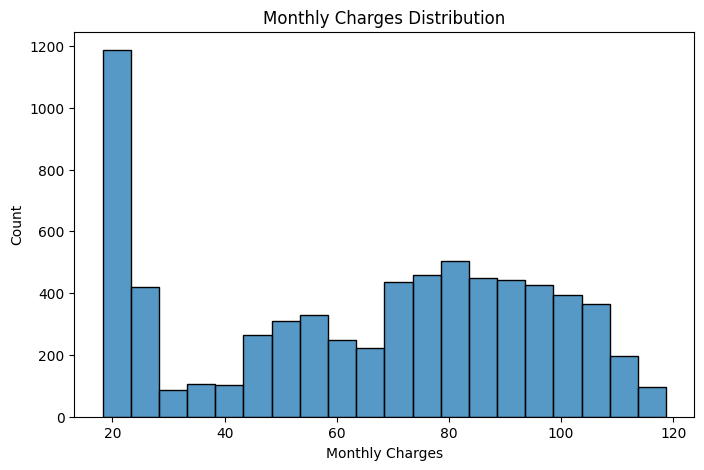

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Monthly Charges'],
    bins=20
)

plt.title('Monthly Charges Distribution')

plt.show()

### Observation

The average monthly charge is $64.76, with customer payments ranging from $18.25 to $118.75 per month.

Key statistics:

- Average Monthly Charge: $64.76
- Median Monthly Charge: $70.35
- 25% of customers pay $35.50 or less
- 50% of customers pay $70.35 or less
- 75% of customers pay $89.85 or less
- Maximum Monthly Charge: $118.75

### Insight

The customer base exhibits a wide range of monthly spending levels, indicating the presence of multiple subscription plans and service combinations.

The median monthly charge ($70.35) is higher than the average monthly charge ($64.76), indicating that a large proportion of customers subscribe to mid-to-high value service plans while a smaller group of lower-paying customers pulls the average downward.

### Business Impact

Monthly Charges directly influence recurring revenue generation and customer value.

Customers paying higher monthly charges contribute more revenue but may also have higher expectations regarding service quality, pricing, and customer support.

### Hypothesis

Customers with higher monthly charges may exhibit different churn behavior compared to customers on lower-priced plans. This relationship will be validated during the churn analysis phase.

### Recommendation

Analyze churn rates across Monthly Charge ranges to determine whether pricing, service bundles, or perceived value contribute to customer attrition.

## Analysis 7: Revenue by Contract Type

### Business Question

Which contract type generates the highest revenue for the company?

### Why Are We Performing This Analysis?

Customer count alone does not indicate business value.

A customer segment may have:

- More customers but lower revenue
- Fewer customers but higher revenue

Therefore, we need to evaluate revenue contribution across contract types.

### Business Objective

Identify the most valuable contract segment and understand how contract duration influences revenue generation.

### Analytical Approach

1. Group customers by Contract Type.
2. Calculate the total revenue generated by each contract segment using Total Charges.
3. Compare revenue contribution across contract types.
4. Identify high-value customer segments for future retention strategies.

### Expected Outcome

This analysis will help answer:

- Which contract segment contributes the most revenue?
- Are long-term contract customers more valuable than short-term customers?
- Which customer segment should receive the highest retention focus?

### Metric Used

Total Revenue = Sum of Total Charges

In [20]:
revenue_by_contract = (
    df.groupby('Contract')['Total Charges']
      .sum()
      .sort_values(ascending=False)
)

revenue_by_contract

Contract
Two year          6283253.7
Month-to-month    5305861.5
One year          4467053.5
Name: Total Charges, dtype: float64

### Visualization: Revenue by Contract Type

The following chart compares total revenue generated across different contract types.

The visualization helps identify the most valuable customer segment from a revenue perspective.

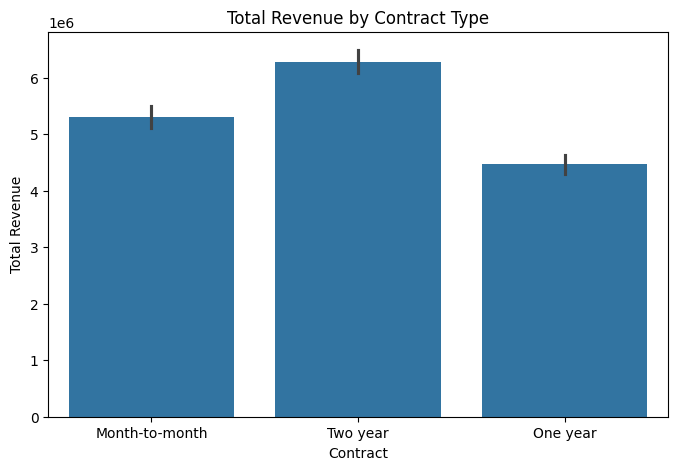

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Contract',
    y='Total Charges',
    estimator='sum'
)

plt.title('Total Revenue by Contract Type')

plt.ylabel('Total Revenue')

plt.show()

### Observation

Revenue generation varies significantly across contract types.

Revenue by Contract Type:

- Two-Year Contract: $6.28 Million
- Month-to-Month Contract: $5.31 Million
- One-Year Contract: $4.47 Million

The Two-Year contract segment generates the highest total revenue despite having fewer customers than the Month-to-Month segment.

### Insight

Customers on longer-term contracts contribute substantially more revenue over their lifetime compared to customers on shorter-term contracts.

Although Month-to-Month contracts represent the largest customer segment, Two-Year customers generate the highest cumulative revenue.

### Business Impact

Long-term contract customers appear to be the most valuable customer segment from a revenue perspective.

Losing customers from this segment could have a significant impact on long-term revenue and profitability.

### Hypothesis

Customers enrolled in longer-term contracts may exhibit lower churn rates than Month-to-Month customers. This relationship will be validated during the churn analysis phase.

### Recommendation

Develop retention strategies that encourage customers to migrate from Month-to-Month plans to longer-term contracts through discounts, loyalty rewards, or bundled service offerings.

## Analysis 8: Revenue by Internet Service

### Business Question

Which internet service type generates the highest revenue for the company?

### Why Are We Performing This Analysis?

Different internet services may contribute differently to revenue generation.

Understanding revenue contribution by service type helps identify the most valuable customer segments and prioritize retention efforts.

### Business Objective

Determine which internet service category contributes the most revenue and assess its importance to overall business performance.

### Analytical Approach

1. Group customers by Internet Service.
2. Calculate total revenue generated by each service category.
3. Compare revenue contribution across service types.

### Expected Outcome

Identify the highest-value internet service segment and understand its contribution to business revenue.

### Metric Used

Total Revenue = Sum of Total Charges

In [22]:
revenue_by_internet = (
    df.groupby('Internet Service')['Total Charges']
      .sum()
      .sort_values(ascending=False)
)

revenue_by_internet

Internet Service
Fiber optic    9923622.95
DSL            5121410.85
No             1011134.90
Name: Total Charges, dtype: float64

### Visualization: Revenue by Internet Service

The following chart compares total revenue generated by each internet service category.

The visualization helps identify the most valuable service segment and its contribution to overall business performance.

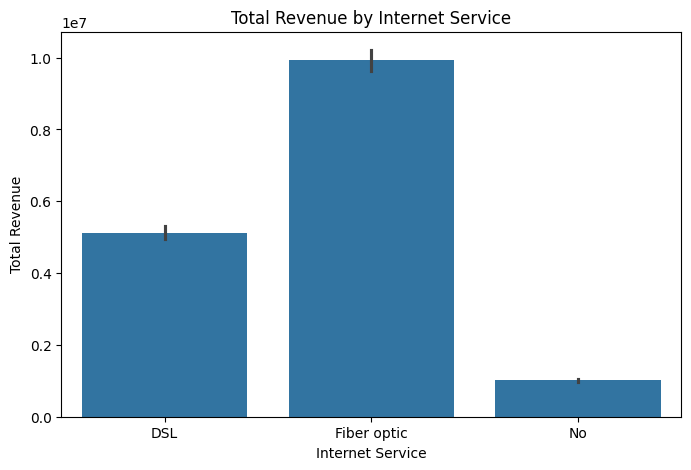

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Internet Service',
    y='Total Charges',
    estimator='sum'
)

plt.title('Total Revenue by Internet Service')

plt.ylabel('Total Revenue')

plt.show()

### Observation

Revenue generation varies significantly across internet service types.

Revenue by Internet Service:

- Fiber Optic: $9.92 Million
- DSL: $5.12 Million
- No Internet Service: $1.01 Million

Fiber Optic customers contribute the highest revenue and account for more revenue than DSL and No Internet Service customers combined.

### Insight

Fiber Optic is the company's most valuable internet service segment from a revenue perspective.

The large revenue contribution suggests that Fiber Optic customers are likely subscribed to higher-value plans and additional service offerings.

### Business Impact

A significant portion of the company's revenue depends on Fiber Optic customers.

Any increase in churn within this segment could have a substantial impact on overall revenue and profitability.

### Hypothesis

Fiber Optic customers may exhibit different retention and churn patterns compared to DSL customers. This relationship will be validated during the churn analysis phase.

### Recommendation

Prioritize customer experience, service quality, and retention initiatives for Fiber Optic customers due to their significant revenue contribution.

## Analysis 9: Customer Distribution by State

### Business Question

Which states have the highest customer concentration?

### Why Are We Performing This Analysis?

Understanding geographic customer distribution helps identify key markets and prioritize regional business strategies.

### Business Objective

Determine where customers are concentrated and assess geographic dependence on specific regions.

### Analytical Approach

1. Count customers by state.
2. Rank states by customer volume.
3. Identify the largest customer markets.

### Expected Outcome

Understand the geographic distribution of the customer base.

### Metric Used

Customer Count

In [24]:
top_states = (
    df['State']
      .value_counts()
      .head(10)
)

top_states

State
California    7043
Name: count, dtype: int64

### Observation

All 7,043 customers belong to California.

### Insight

The dataset represents customers from a single state and therefore does not support state-level comparisons.

### Business Impact

State-wise customer distribution and state-wise churn analysis cannot be performed using this dataset.

### Next Step

Customer distribution will be analyzed at the city level to identify geographic concentration patterns within California.

## Analysis 10: Top Cities by Customer Count

### Business Question

Which cities contain the largest customer populations?

### Why Are We Performing This Analysis?

Understanding customer concentration by city helps identify key markets and areas requiring focused retention strategies.

### Business Objective

Identify cities with the highest customer presence and evaluate geographic concentration within California.

### Analytical Approach

1. Count customers by city.
2. Rank cities by customer volume.
3. Identify the largest customer markets.

### Expected Outcome

Determine which cities contribute the most customers to the business.

### Metric Used

Customer Count

In [25]:
top_cities = (
    df['City']
      .value_counts()
      .head(10)
)

top_cities

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
Fresno            64
Long Beach        60
Oakland           52
Stockton          44
Glendale          40
Name: count, dtype: int64

### Visualization: Top 10 Cities by Customer Count

The following chart displays the top 10 cities with the highest customer concentration.

The visualization helps identify key customer markets and geographic concentration within California.

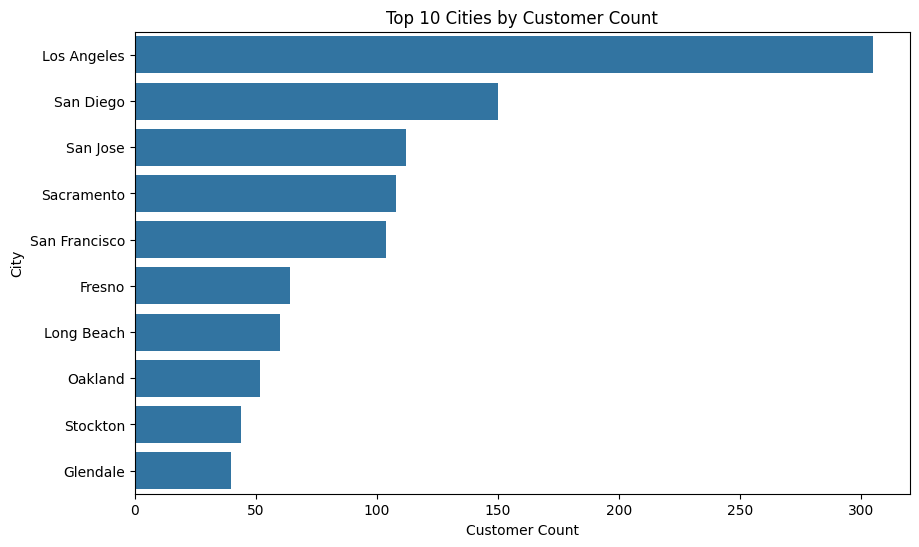

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title('Top 10 Cities by Customer Count')

plt.xlabel('Customer Count')
plt.ylabel('City')

plt.show()

### Observation

Customer distribution is concentrated in a few major California cities.

Top Cities by Customer Count:

- Los Angeles: 305 customers
- San Diego: 150 customers
- San Jose: 112 customers
- Sacramento: 108 customers
- San Francisco: 104 customers

Los Angeles has more than twice the customer count of the second-largest city, San Diego.

### Insight

Major metropolitan areas account for a significant portion of the customer base.

Los Angeles represents the largest customer market and appears to be a critical geographic region for the business.

### Business Impact

Customer acquisition, retention campaigns, and service improvements implemented in Los Angeles could influence a substantial portion of the customer population.

Geographic concentration also creates opportunities for targeted regional marketing initiatives.

### Hypothesis

Customer behavior and churn patterns may differ across cities due to differences in demographics, competition, service availability, and pricing sensitivity.

This relationship will be investigated during geographic churn analysis.

### Recommendation

Perform city-level churn analysis to identify whether high-customer-volume cities experience higher customer attrition rates compared to smaller markets.

## Analysis 11: Top Cities by Revenue

### Business Question

Which cities generate the highest revenue for the company?

### Why Are We Performing This Analysis?

Customer volume does not always translate into revenue generation.

A city with fewer customers may generate more revenue if customers subscribe to higher-value services.

### Business Objective

Identify the most valuable geographic markets from a revenue perspective.

### Analytical Approach

1. Group customers by city.
2. Calculate total revenue generated by each city.
3. Rank cities by revenue contribution.

### Expected Outcome

Determine which cities contribute the most revenue and should receive focused retention efforts.

### Metric Used

Total Revenue = Sum of Total Charges

In [27]:
top_revenue_cities = (
    df.groupby('City')['Total Charges']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue_cities

City
Los Angeles      647751.25
San Diego        354896.60
Sacramento       256295.05
San Jose         243735.55
San Francisco    221624.65
Fresno           154890.10
Long Beach       141928.85
Oakland          114974.75
Whittier          96832.30
Bakersfield       93714.40
Name: Total Charges, dtype: float64

### Visualization: Top 10 Cities by Revenue

The following chart compares total revenue generated by the top revenue-contributing cities.

The visualization helps identify the most valuable geographic markets and supports location-based retention strategies.

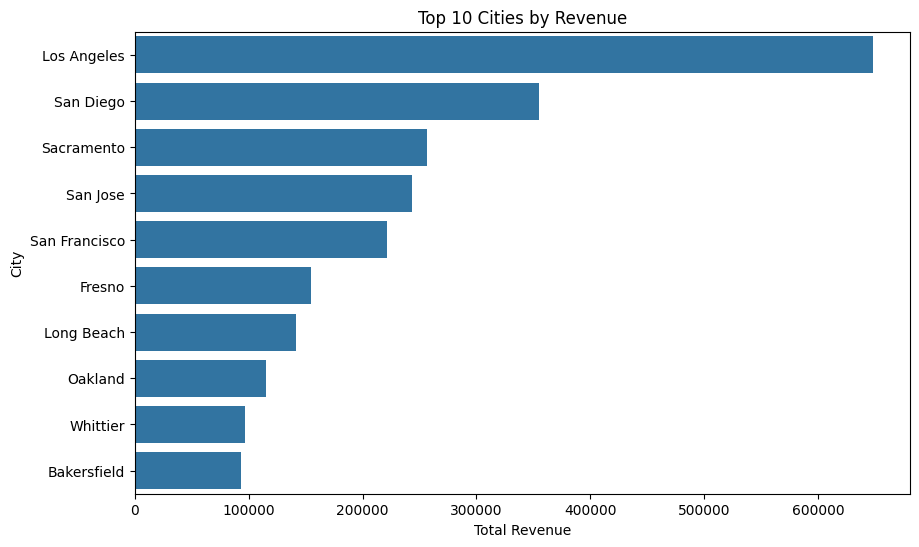

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_revenue_cities.values,
    y=top_revenue_cities.index
)

plt.title('Top 10 Cities by Revenue')

plt.xlabel('Total Revenue')
plt.ylabel('City')

plt.show()

### Observation

Revenue generation is concentrated within a few major California cities.

Top Revenue-Contributing Cities:

- Los Angeles: $647,751
- San Diego: $354,897
- Sacramento: $256,295
- San Jose: $243,736
- San Francisco: $221,625

Los Angeles generates nearly twice the revenue of San Diego, making it the company's most valuable geographic market.

### Insight

Major metropolitan areas contribute a significant portion of overall business revenue.

The strong revenue contribution from Los Angeles indicates that customer acquisition and retention efforts in this city have a substantial impact on business performance.

### Business Impact

Revenue concentration within a limited number of cities creates both opportunities and risks.

Retaining customers in high-revenue cities can significantly improve revenue stability and long-term growth.

### Hypothesis

Customer churn patterns may differ across cities due to market competition, demographics, and service adoption levels.

This relationship will be investigated during geographic churn analysis.

### Recommendation

Prioritize retention campaigns and customer experience improvements in high-revenue cities, particularly Los Angeles, San Diego, and Sacramento.

# Customer Analysis Summary

## Objective

The purpose of this analysis was to understand customer demographics, customer behavior, service adoption, revenue contribution, and geographic distribution before performing churn analysis.

## Key Findings

### Customer Demographics

- The customer base is evenly distributed between male and female customers.
- Senior citizens represent approximately 16% of the customer population.

### Customer Behavior

- Customers remain with the company for an average of 32.37 months.
- The average monthly charge is $64.76.

### Contract Analysis

- Month-to-Month contracts account for more than 55% of customers.
- Two-Year contracts generate the highest total revenue despite having fewer customers.

### Internet Service Analysis

- Fiber Optic is the largest internet service segment.
- Fiber Optic customers contribute approximately $9.92 million in revenue, making them the most valuable service segment.

### Geographic Analysis

- Los Angeles is the largest customer market and highest revenue-contributing city.
- Revenue generation is concentrated within a few major California cities.

## Business Hypotheses for Churn Analysis

The following hypotheses will be tested in the next phase:

1. Month-to-Month customers churn more frequently than long-term contract customers.

2. Fiber Optic customers exhibit different churn behavior compared to DSL customers.

3. Customers with shorter tenure are more likely to churn.

4. Customer churn varies across geographic regions.

5. High-value customers demonstrate different retention patterns than lower-value customers.

## Next Phase

The next notebook will focus on identifying the drivers of customer churn and customer retention through detailed churn analysis and customer segmentation.